In [85]:
# ニューラルネットワークの学習
# データから学習する
# データ駆動
# 訓練データとテストデータ
# 損失関数

In [51]:
# 2乗和誤差の実装
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

In [52]:
# 「2」を正解とする
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# 「2」の確率が最も高い場合
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(mean_squared_error(np.array(y), np.array(t)))

0.09750000000000003


In [53]:
# 交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [54]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338


In [55]:
# ミニバッチ学習
# MNISTデータセットを読み込む
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [56]:
# ランダムに10枚だけ抜き出す
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

print(x_batch.shape)
print(t_batch.shape)

(10, 784)
(10, 10)


In [57]:
# 【バッチ対応版】交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y)) / batch_size

In [58]:
# 教師データがラベルとしてあたえられた場合
# 交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

In [59]:
# なぜ損失関数を設定するのか？
# 数値微分
# 微分

In [60]:
# 数値微分の実装
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2*h)

In [61]:
# 数値微分の例
def function_1(x):
    return 0.01*x**2 + 0.1*x

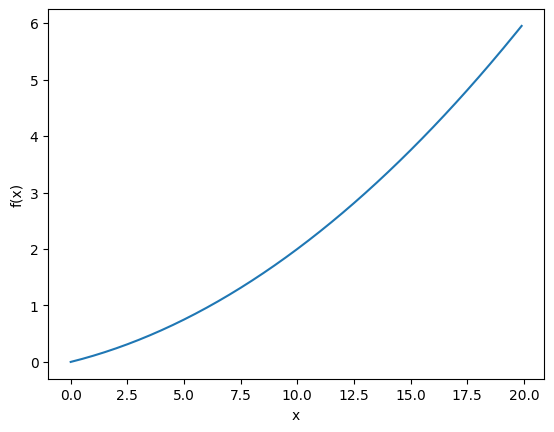

In [62]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1) # 0から20まで、0.1刻みのx配列
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [63]:
# 関数の微分を計算してみる
numerical_diff(function_1, 5)

0.1999999999990898

In [64]:
numerical_diff(function_1, 10)

0.2999999999986347

In [65]:
# 偏微分の実装
def function_2(x):
    return x[0]**2 + x[1]**2


In [66]:
# 勾配
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]
        # f(x+h)の計算
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h)の計算
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 値を元に戻す

    return grad

In [67]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [68]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [69]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

In [70]:
# 勾配法
def gradiene_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x

In [71]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
gradiene_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

In [72]:
# 歩幅が大きすぎる例
init_x = np.array([-3.0, 4.0])
result = gradiene_descent(function_2, init_x=init_x, lr=10.0, step_num=100)
print(result)

[-2.58983747e+13 -1.29524862e+12]


In [73]:
# 歩幅が小さすぎる例
init_x = np.array([-3.0, 4.0])
result = gradiene_descent(function_2, init_x=init_x, lr=1e-10, step_num=100)
print(result)

[-2.99999994  3.99999992]


In [74]:
# ニューラルネットワークに対する勾配
import sys, os
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

rng = np.random.default_rng()

class simpleNet:
    def __init__(self):
        self.W = rng.random((2, 3))

    def predict(self, x):
        return x @ self.W
    
    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss


In [75]:
# simplrNetを使ってみる
net = simpleNet()
print(net.W) # 重みパラメータ

[[0.21086584 0.36361065 0.26959372]
 [0.30617101 0.29722566 0.66355943]]


In [76]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[0.40207341 0.48566949 0.75895972]


In [77]:
t = np.array([0, 0, 1])
net.loss(x, t)

np.float64(0.9004553611813917)

In [78]:
# 勾配を求める
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.17064536  0.18552387 -0.35616923]
 [ 0.25596804  0.27828581 -0.53425385]]


In [79]:
f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)

In [80]:
# 学習アルゴリズムの実装

In [81]:
# 2層ニューラルネットワークのクラス
import sys, os
sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient

class TwoLayerNet:

    def __init__ (self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 重みの初期化
        self.params = {}
        self.params["W1"] = weight_init_std * \
            rng.random((input_size, hidden_size))
        self.params["b1"] = np.zeros(hidden_size)
        self.params["W2"] = weight_init_std * \
            rng.random((hidden_size, output_size))
        self.params["b2"] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]

        a1 = x @ W1 + b1
        z1 = sigmoid(a1)
        a2 = z1 @ W2 + b2
        z2 = softmax(a2)

        return y

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # x:入力データ, t:教師データ
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads["W1"] = numerical_gradient(loss_W, self.params["W1"])
        grads["b1"] = numerical_gradient(loss_W, self.params["b1"])
        grads["W2"] = numerical_gradient(loss_W, self.params["W2"])
        grads["b2"] = numerical_gradient(loss_W, self.params["b2"])

        return grads

In [82]:
net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
print(net.params["W1"].shape)
print(net.params["b1"].shape)
print(net.params["W2"].shape)
print(net.params["b2"].shape)

(784, 100)
(100,)
(100, 10)
(10,)


In [88]:
# ミニバッチ学習の実装
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

# ハイパーパラメータ
iteres_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iteres_num):
    # ミニバッチの取得
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 勾配の計算
    grad = network.gradient(x_batch, t_batch)

    # パラメータの更新
    for key in ["W1", "b1", "W2", "b2"]:
        network.params[key] -= learning_rate * grad[key]

    # 学習経過の記録
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

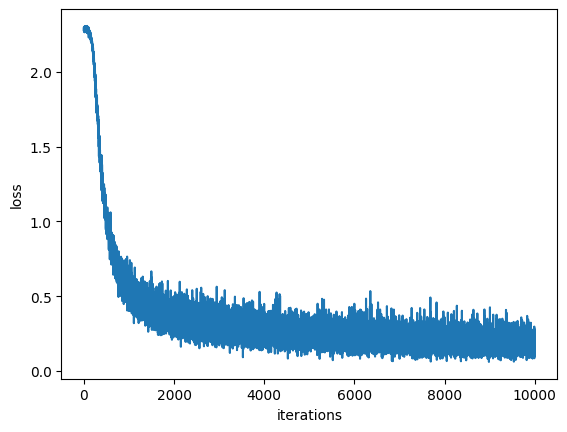

In [89]:
import matplotlib.pyplot as plt

# グラフの描画
plt.plot(train_loss_list)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.show()